In [2]:
import numpy as np
import pandas as pd

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import scipy
import plotly
import openpyxl


import xgboost
import streamlit

print("🎉 ML Workshop Environment Ready")

🎉 ML Workshop Environment Ready


In [4]:
data = pd.read_csv('titanic.csv')
data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [5]:
#Understanding the data --->info(),describe(),columns(),unique(),value_counts:
data.info() #Complete information of the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
#reading columns
data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [7]:
#We will seperate the columns
data.dtypes;
data.select_dtypes(include='object') #object columns
data.select_dtypes(include = ['int','float'])

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.2500
1,2,1,1,38.0,1,0,71.2833
2,3,1,3,26.0,0,0,7.9250
3,4,1,1,35.0,1,0,53.1000
4,5,0,3,35.0,0,0,8.0500
...,...,...,...,...,...,...,...
886,887,0,2,27.0,0,0,13.0000
887,888,1,1,19.0,0,0,30.0000
888,889,0,3,NaN,1,2,23.4500
889,890,1,1,26.0,0,0,30.0000


In [8]:
#Total number of passengers in the ship
print('Total number of passengers in the ship are',len(data))

Total number of passengers in the ship are 891


In [9]:
#Statistical Distribution --->describe()
data.describe() #default ---> numerical columns only

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [10]:
data.describe(include='object')
#top returns most occuring value
#freq returns the count of the most occuring value

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,4,644


In [11]:
#We try to understand the unique values in the columns
data['Sex'].unique()

array(['male', 'female'], dtype=object)

In [12]:
data['Embarked'].unique() #Embarked is place of travel

array(['S', 'C', 'Q', nan], dtype=object)

In [13]:
data['Cabin'].unique();
data['Pclass'].unique()

array([3, 1, 2], dtype=int64)

In [14]:
data['Survived'].unique()


array([0, 1], dtype=int64)

In [15]:
data['SibSp'].unique()

array([1, 0, 3, 4, 2, 5, 8], dtype=int64)

In [16]:
data['Parch'].unique()


array([0, 1, 2, 5, 3, 4, 6], dtype=int64)

In [17]:
#Count of each unique value
data['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [18]:
data['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [19]:
data['Pclass'].value_counts();
data['Pclass'].value_counts(ascending=True)

Pclass
2    184
1    216
3    491
Name: count, dtype: int64

In [20]:
data['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [21]:
data['Age'].value_counts().head(30) #head() it returns top samples by default\
#it is 5

Age
24.0    30
22.0    27
18.0    26
19.0    25
28.0    25
30.0    25
21.0    24
25.0    23
36.0    22
29.0    20
32.0    18
35.0    18
27.0    18
26.0    18
16.0    17
31.0    17
20.0    15
34.0    15
33.0    15
23.0    15
39.0    14
40.0    13
17.0    13
42.0    13
45.0    12
38.0    11
50.0    10
2.0     10
4.0     10
44.0     9
Name: count, dtype: int64

In [22]:
#to get any random samples in the dataset
data.sample(15)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
626,627,0,2,"Kirkland, Rev. Charles Leonard",male,57.0,0,0,219533,12.3500,NaN,Q
107,108,1,3,"Moss, Mr. Albert Johan",male,NaN,0,0,312991,7.7750,NaN,S
423,424,0,3,"Danbom, Mrs. Ernst Gilbert (Anna Sigrid Maria ...",female,28.0,1,1,347080,14.4000,NaN,S
222,223,0,3,"Green, Mr. George Henry",male,51.0,0,0,21440,8.0500,NaN,S
649,650,1,3,"Stanley, Miss. Amy Zillah Elsie",female,23.0,0,0,CA. 2314,7.5500,NaN,S
251,252,0,3,"Strom, Mrs. Wilhelm (Elna Matilda Persson)",female,29.0,1,1,347054,10.4625,G6,S
249,250,0,2,"Carter, Rev. Ernest Courtenay",male,54.0,1,0,244252,26.0000,NaN,S
31,32,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,NaN,1,0,PC 17569,146.5208,B78,C
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
450,451,0,2,"West, Mr. Edwy Arthur",male,36.0,1,2,C.A. 34651,27.7500,NaN,S


In [23]:
#DataVisualization --> matplotlib,seaborn,plotly
import matplotlib.pyplot as plt #!pip install matplotlib


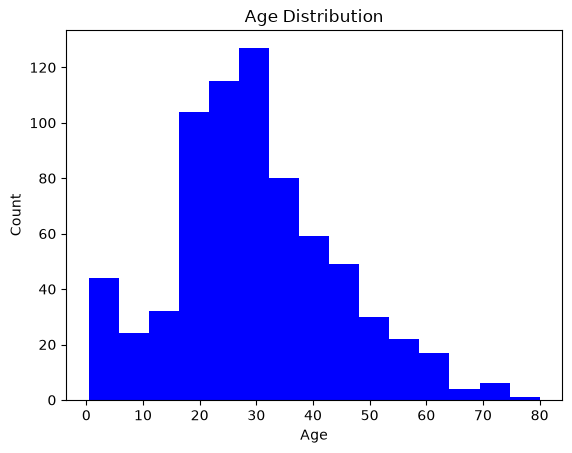

In [24]:
#Distribution of Age
plt.hist(data['Age'],bins=15,color='blue')
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age Distribution")
plt.show()

[30. 17. 15.  9. 29. 64. 67. 70. 83. 62. 51. 40. 35. 27. 35. 23. 15.  9.
 11. 11.  4.  2.  3.  1.  1.]
<BarContainer object of 25 artists>


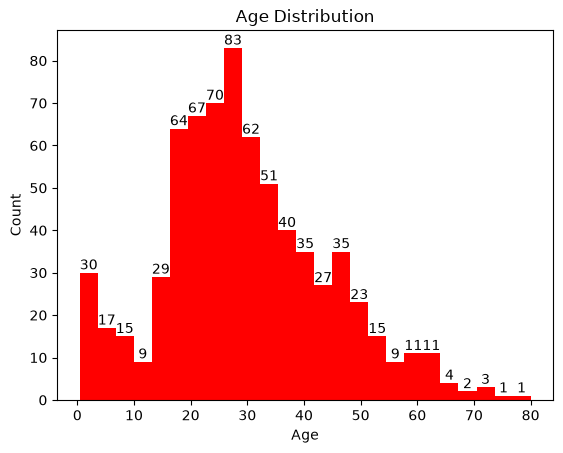

In [25]:
#Display the count of the bars in histogram
#Distribution of Age
counts,edges,bars = plt.hist(data['Age'],bins=25,color='red')
print(counts)
print(bars)
plt.xlabel("Age")
plt.ylabel("Count")
plt.bar_label(bars)
plt.title("Age Distribution")
plt.show()

<Axes: xlabel='Sex'>

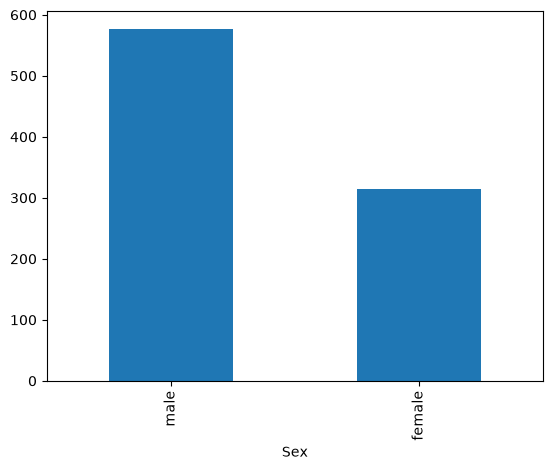

In [26]:
#bar plot representation
data['Sex'].value_counts().plot(kind='bar')

<Axes: ylabel='Pclass'>

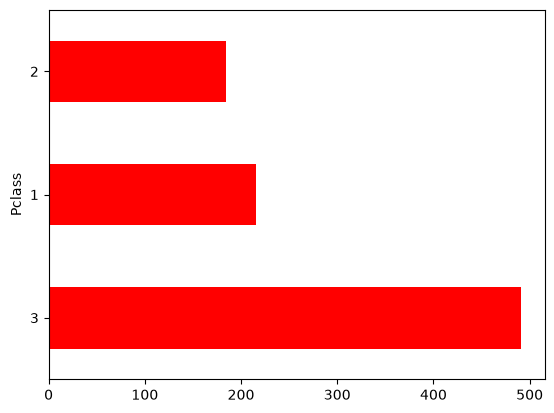

In [27]:
data['Pclass'].value_counts().plot(kind='barh',color = 'red')

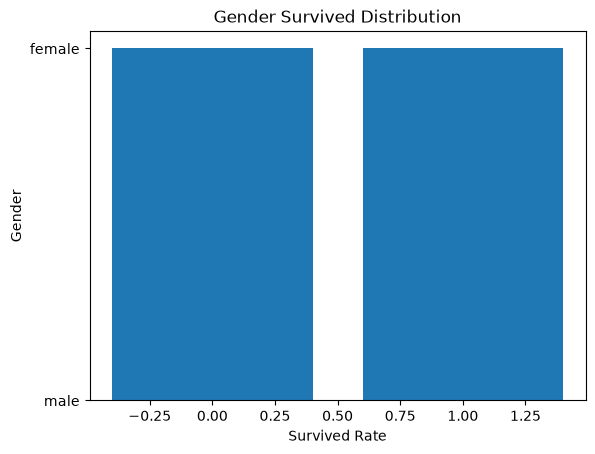

In [28]:
plt.bar(data['Survived'],data['Sex'])
plt.xlabel("Survived Rate")
plt.ylabel("Gender")
plt.title("Gender Survived Distribution")
plt.show()

In [29]:
data['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [30]:
#549 / (549+342)
index = data['Survived'].value_counts().keys().tolist()
print(index)
labels = data['Survived'].value_counts().values.tolist()
print(labels)

[0, 1]
[549, 342]


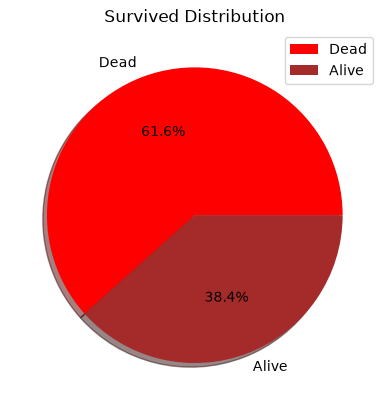

In [31]:
#Pie Chart
plt.pie(x = labels,
        labels = ['Dead','Alive'],
       colors = ['red','brown'],
       autopct="%.1f%%",
       shadow=True)
plt.title("Survived Distribution")
plt.legend()
plt.show()

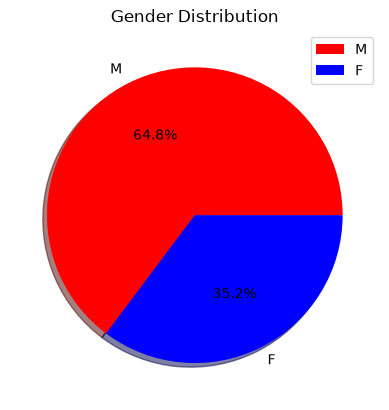

In [32]:
#Pie Chart
plt.pie(x = [577,314],
        labels = ['M','F'],
       colors = ['red','blue'],
       autopct="%.1f%%",
       shadow=True)
plt.title("Gender Distribution")
plt.legend()
plt.show()

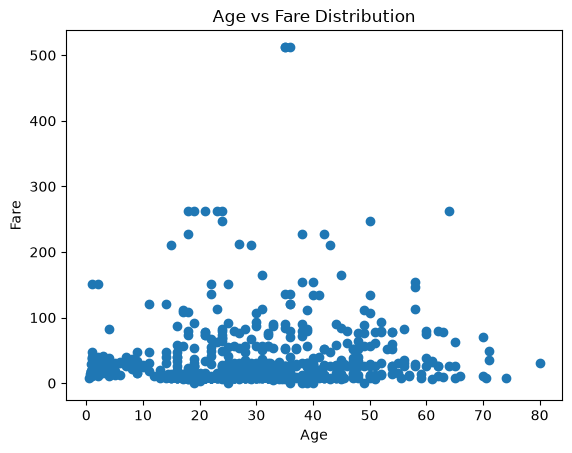

In [33]:
#pairwise relationship --> scatterplot()
plt.scatter(x=data['Age'],
            y=data['Fare'])
plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Age vs Fare Distribution")
plt.show()

In [34]:
import plotly
#!pip install cufflinks

In [35]:
import plotly as py
import plotly.graph_objects as go

In [36]:
from plotly.offline import init_notebook_mode,iplot
init_notebook_mode(connected=True)

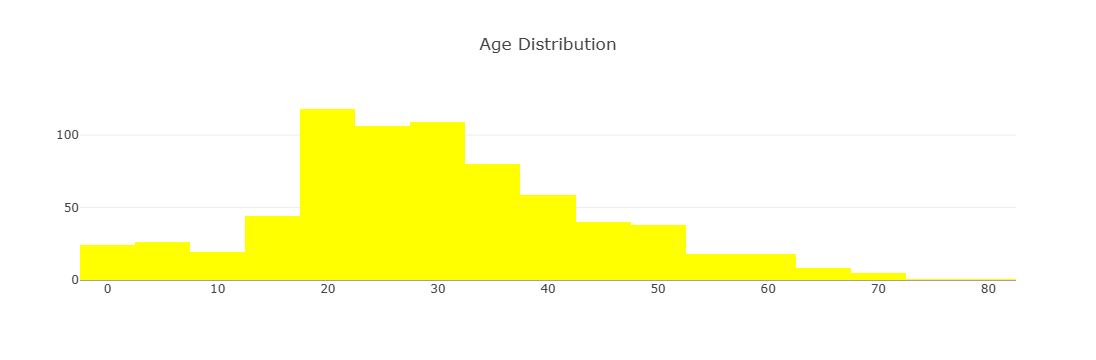

In [37]:
trace = go.Histogram(x = data['Age'],
                     nbinsx=20,
                     marker={'color':'yellow'})
layout = go.Layout(title='Age Distribution')
fig = go.Figure(data=trace,layout=layout)
fig.show()

In [38]:
print(index)
print(labels)

[0, 1]
[549, 342]


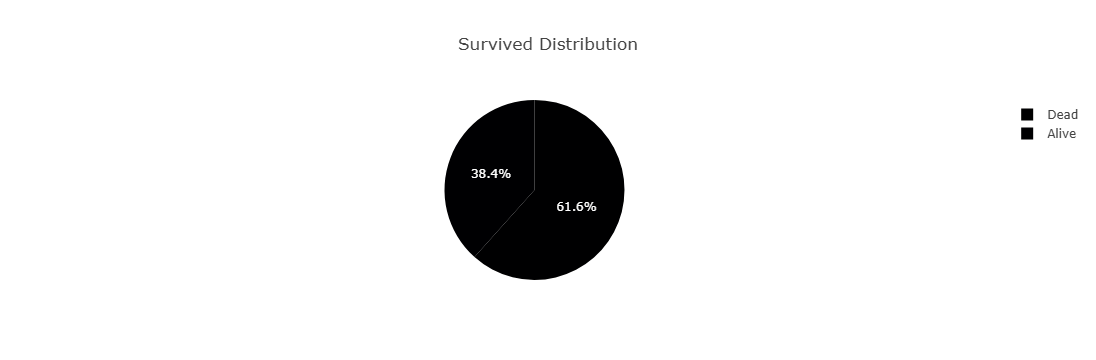

In [39]:
#Now we will display for Piechart
trace = go.Pie(labels=['Dead','Alive'],
               values=[549,342],
               )
layout = go.Layout(title = 'Survived Distribution')
fig = go.Figure(data=trace,layout=layout)
fig.show()

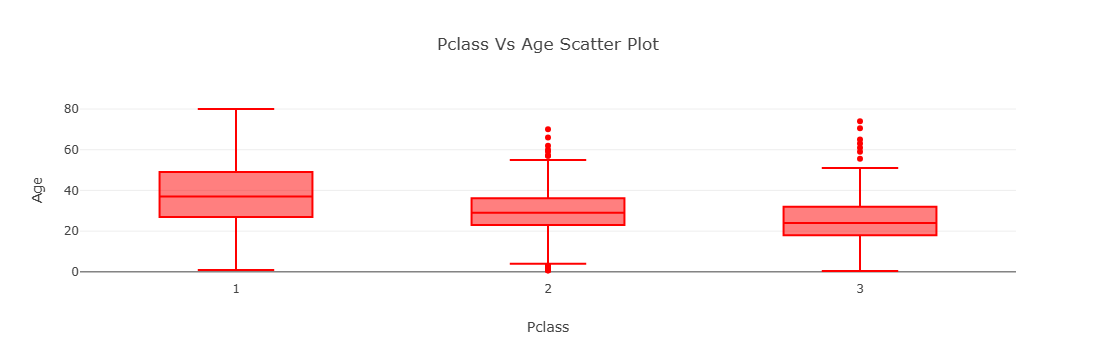

In [40]:
#Box plot and Scatter Plot
trace = go.Box(x=data['Pclass'],
               y=data['Age'],
               marker={'color':'red'})
#defining layout
layout = go.Layout(title='Pclass Vs Age Scatter Plot',
                   xaxis=dict(title='Pclass'),
                   yaxis={'title':'Age'},
                   hovermode='closest')
fig = go.Figure(data=trace,layout = layout)
fig.show()

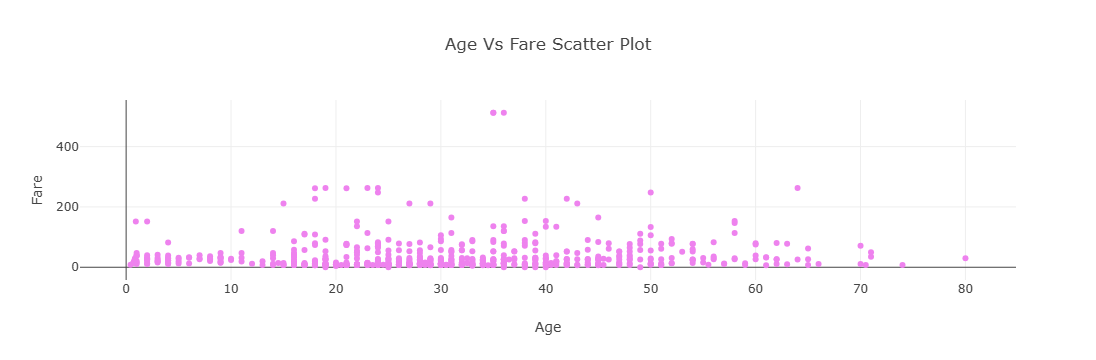

In [41]:
#Scatter Plot representation --> Age vs Fare
trace = go.Scatter(x=data['Age'],y=data['Fare'],
                   mode='markers',
                   marker={'color':'violet'})
#defining layout
layout = go.Layout(title='Age Vs Fare Scatter Plot',
                   xaxis={'title':'Age'},
                   yaxis={'title':'Fare'},
                   )
fig = go.Figure(data=trace,layout=layout)
fig.show()

In [42]:
#Understanding the missing values and filling the missing values
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [43]:
print(data['Age'].mean())

29.69911764705882


In [44]:
data['Age'].fillna(data['Age'].mean(),inplace=True)

C:\Users\Asus\AppData\Local\Temp\ipykernel_4328\1761542025.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Age'].fillna(data['Age'].mean(),inplace=True)


In [45]:
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [46]:
data['Embarked'].fillna('S',inplace=True)

C:\Users\Asus\AppData\Local\Temp\ipykernel_4328\1306493021.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Embarked'].fillna('S',inplace=True)


In [47]:
data.drop(columns=['Cabin'],inplace=True)

In [48]:
data.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [49]:
# Feature Enginneering --> Feature encoding ( It is process of converting categorical values into numerical values)

In [50]:
data.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,S
5,6,0,3,"Moran, Mr. James",male,29.699118,0,0,330877,8.4583,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.000000,0,0,17463,51.8625,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.000000,3,1,349909,21.0750,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.000000,0,2,347742,11.1333,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.000000,1,0,237736,30.0708,C


In [51]:
#get_dummies
pclass=pd.get_dummies(data['Name'],drop_first=True,dtype=int)
pclass

,"Abbott, Mr. Rossmore Edward","Abbott, Mrs. Stanton (Rosa Hunt)","Abelson, Mr. Samuel","Abelson, Mrs. Samuel (Hannah Wizosky)","Adahl, Mr. Mauritz Nils Martin","Adams, Mr. John","Ahlin, Mrs. Johan (Johanna Persdotter Larsson)","Aks, Mrs. Sam (Leah Rosen)","Albimona, Mr. Nassef Cassem","Alexander, Mr. William",...,"Yrois, Miss. Henriette (""Mrs Harbeck"")","Zabour, Miss. Hileni","Zabour, Miss. Thamine","Zimmerman, Mr. Leo","de Messemaeker, Mrs. Guillaume Joseph (Emma)","de Mulder, Mr. Theodore","de Pelsmaeker, Mr. Alfons","del Carlo, Mr. Sebastiano","van Billiard, Mr. Austin Blyler","van Melkebeke, Mr. Philemon"
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
887,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
888,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
889,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [52]:
#get_dummies
embarked=pd.get_dummies(data['Embarked'])
embarked

,C,Q,S
0,False,False,True
1,True,False,False
2,False,False,True
3,False,False,True
4,False,False,True
...,...,...,...
886,False,False,True
887,False,False,True
888,False,False,True
889,True,False,False


In [53]:
#get_dummies
gender=pd.get_dummies(data['Sex'])
gender

,female,male
0,False,True
1,True,False
2,True,False
3,True,False
4,False,True
...,...,...
886,False,True
887,True,False
888,True,False
889,False,True


In [54]:
#concatination of all tables
final_data = pd.concat([data,pclass,gender,embarked],
                       axis=1)
final_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,"de Mulder, Mr. Theodore","de Pelsmaeker, Mr. Alfons","del Carlo, Mr. Sebastiano","van Billiard, Mr. Austin Blyler","van Melkebeke, Mr. Philemon",female,male,C,Q,S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,...,0,0,0,0,0,False,True,False,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,...,0,0,0,0,0,True,False,True,False,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,...,0,0,0,0,0,True,False,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,...,0,0,0,0,0,True,False,False,False,True
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,...,0,0,0,0,0,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,...,0,0,0,0,0,False,True,False,False,True
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,...,0,0,0,0,0,True,False,False,False,True
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,...,0,0,0,0,0,True,False,False,False,True
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.0000,...,0,0,0,0,0,False,True,True,False,False


In [55]:
final_data.drop(columns=['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'], inplace=True)

final_data.head()

,Survived,"Abbott, Mr. Rossmore Edward","Abbott, Mrs. Stanton (Rosa Hunt)","Abelson, Mr. Samuel","Abelson, Mrs. Samuel (Hannah Wizosky)","Adahl, Mr. Mauritz Nils Martin","Adams, Mr. John","Ahlin, Mrs. Johan (Johanna Persdotter Larsson)","Aks, Mrs. Sam (Leah Rosen)","Albimona, Mr. Nassef Cassem",...,"de Mulder, Mr. Theodore","de Pelsmaeker, Mr. Alfons","del Carlo, Mr. Sebastiano","van Billiard, Mr. Austin Blyler","van Melkebeke, Mr. Philemon",female,male,C,Q,S
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,False,True,False,False,True
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,True,False,True,False,False
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,True,False,False,False,True
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,True,False,False,False,True
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,False,True,False,False,True


In [56]:
final_data.head()

,Survived,"Abbott, Mr. Rossmore Edward","Abbott, Mrs. Stanton (Rosa Hunt)","Abelson, Mr. Samuel","Abelson, Mrs. Samuel (Hannah Wizosky)","Adahl, Mr. Mauritz Nils Martin","Adams, Mr. John","Ahlin, Mrs. Johan (Johanna Persdotter Larsson)","Aks, Mrs. Sam (Leah Rosen)","Albimona, Mr. Nassef Cassem",...,"de Mulder, Mr. Theodore","de Pelsmaeker, Mr. Alfons","del Carlo, Mr. Sebastiano","van Billiard, Mr. Austin Blyler","van Melkebeke, Mr. Philemon",female,male,C,Q,S
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,False,True,False,False,True
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,True,False,True,False,False
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,True,False,False,False,True
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,True,False,False,False,True
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,False,True,False,False,True


In [57]:
print(final_data.columns)

Index(['Survived', 'Abbott, Mr. Rossmore Edward',
       'Abbott, Mrs. Stanton (Rosa Hunt)', 'Abelson, Mr. Samuel',
       'Abelson, Mrs. Samuel (Hannah Wizosky)',
       'Adahl, Mr. Mauritz Nils Martin', 'Adams, Mr. John',
       'Ahlin, Mrs. Johan (Johanna Persdotter Larsson)',
       'Aks, Mrs. Sam (Leah Rosen)', 'Albimona, Mr. Nassef Cassem',
       ...
       'de Mulder, Mr. Theodore', 'de Pelsmaeker, Mr. Alfons',
       'del Carlo, Mr. Sebastiano', 'van Billiard, Mr. Austin Blyler',
       'van Melkebeke, Mr. Philemon', 'female', 'male', 'C', 'Q', 'S'],
      dtype='object', length=896)


In [58]:
final_data.head()

,Survived,"Abbott, Mr. Rossmore Edward","Abbott, Mrs. Stanton (Rosa Hunt)","Abelson, Mr. Samuel","Abelson, Mrs. Samuel (Hannah Wizosky)","Adahl, Mr. Mauritz Nils Martin","Adams, Mr. John","Ahlin, Mrs. Johan (Johanna Persdotter Larsson)","Aks, Mrs. Sam (Leah Rosen)","Albimona, Mr. Nassef Cassem",...,"de Mulder, Mr. Theodore","de Pelsmaeker, Mr. Alfons","del Carlo, Mr. Sebastiano","van Billiard, Mr. Austin Blyler","van Melkebeke, Mr. Philemon",female,male,C,Q,S
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,False,True,False,False,True
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,True,False,True,False,False
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,True,False,False,False,True
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,True,False,False,False,True
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,False,True,False,False,True


In [59]:
import numpy as np
import pandas as pd
import matplotlib as plt
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, StratifiedShuffleSplit, cross_val_score
from sklearn.metrics import (
            accuracy_score,precision_score, recall_score, confusion_matrix, classification_report, roc_curve, ConfusionMatrixDisplay)

In [60]:
#Loading The Data
model_data = final_data.copy()
#model_data
#model_data.info()

In [61]:
model_data = final_data.copy()

model_data.columns = model_data.columns.astype(str)

x = model_data.drop(columns='Survived')
y = model_data['Survived'].astype(int)

x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Columns: 895 entries, Abbott, Mr. Rossmore Edward to S
dtypes: bool(5), int32(890)
memory usage: 3.0 MB


In [62]:
pclass = pd.get_dummies(data['Pclass'], drop_first=True, dtype=int)
sex = pd.get_dummies(data['Sex'], drop_first=False, dtype=int)
embarked = pd.get_dummies(data['Embarked'], drop_first=True, dtype=int)

final_data = pd.concat(
    [
        data[['Age', 'SibSp', 'Parch', 'Fare', 'Survived']],
        pclass,
        sex,
        embarked
    ],
    axis=1
)

final_data.head()

,Age,SibSp,Parch,Fare,Survived,2,3,female,male,Q,S
0,22.0,1,0,7.2500,0,0,1,0,1,0,1
1,38.0,1,0,71.2833,1,0,0,1,0,0,0
2,26.0,0,0,7.9250,1,0,1,1,0,0,1
3,35.0,1,0,53.1000,1,0,0,1,0,0,1
4,35.0,0,0,8.0500,0,0,1,0,1,0,1


In [63]:
y.info();
y

<class 'pandas.core.series.Series'>
RangeIndex: 891 entries, 0 to 890
Series name: Survived
Non-Null Count  Dtype
--------------  -----
891 non-null    int32
dtypes: int32(1)
memory usage: 3.6 KB


0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int32

In [64]:
print("Input Shape:",x.shape)
print("Output Shape:",y.shape)

Input Shape: (891, 895)
Output Shape: (891,)


In [65]:
x_train,x_test,y_train,y_test = train_test_split(x,y,
                                                 test_size=0.2,
                                                 stratify=y,
                                                 random_state=42)
logistic_model = Pipeline([
    ("scale",StandardScaler()),
    ("classifier",LogisticRegression(max_iter=100,random_state=42))]
)
logistic_model
#Start Building The Model
logistic_model.fit(x_train,y_train)
logistic_model_prob = logistic_model.predict_proba(x_test)
logistic_predictions = logistic_model.predict(x_test)
print(logistic_model_prob[:10])
print(logistic_predictions[:10])

[[0.96463795 0.03536205]
 [0.96463795 0.03536205]
 [0.87244195 0.12755805]
 [0.96463795 0.03536205]
 [0.19530931 0.80469069]
 [0.29022422 0.70977578]
 [0.29022422 0.70977578]
 [0.96463795 0.03536205]
 [0.87244195 0.12755805]
 [0.96463795 0.03536205]]
[0 0 0 0 1 1 1 0 0 0]


In [66]:
from sklearn.metrics import confusion_matrix

In [67]:
print(confusion_matrix(y_test,logistic_predictions))

[[94 16]
 [24 45]]


In [68]:
from sklearn.metrics import classification_report

In [69]:
print(classification_report(y_test,logistic_predictions))

              precision    recall  f1-score   support

           0       0.80      0.85      0.82       110
           1       0.74      0.65      0.69        69

    accuracy                           0.78       179
   macro avg       0.77      0.75      0.76       179
weighted avg       0.77      0.78      0.77       179



In [73]:
from sklearn.metrics import f1_score,roc_auc_score

In [77]:
def evaluate_model(name, y_true, prediction, probability):
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        prediction,
        labels=(0, 1)
    ).ravel()

    # If predict_proba() returned both class probabilities,
    # use only the probability of class 1
    if probability.ndim == 2:
        probability = probability[:, 1]

    return {
        'Model_name': name,
        'Accuracy': accuracy_score(y_true, prediction),
        'Recall': recall_score(y_true, prediction, zero_division=0),
        'Specificity': tn / (tn + fp),
        'F1_Score': f1_score(y_true, prediction, zero_division=0),
        'ROC_AUC': roc_auc_score(y_true, probability),
        'TN': tn,
        'FP': fp,
        'TP': tp,
        'FN': fn
    }


logistic_metrics = evaluate_model(
    "Logistic Regression",
    y_test,
    logistic_predictions,
    logistic_model_prob
)

logistic_metrics

{'Model_name': 'Logistic Regression',
 'Accuracy': 0.776536312849162,
 'Recall': 0.6521739130434783,
 'Specificity': 0.8545454545454545,
 'F1_Score': 0.6923076923076923,
 'ROC_AUC': 0.761528326745718,
 'TN': 94,
 'FP': 16,
 'TP': 45,
 'FN': 24}

In [79]:
import matplotlib as plt

AttributeError: module 'matplotlib' has no attribute 'title'

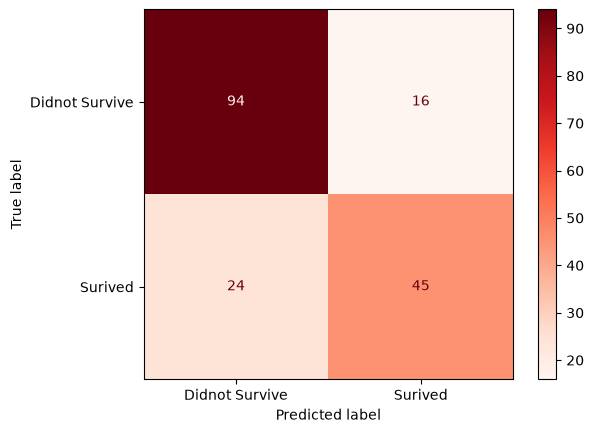

In [80]:
ConfusionMatrixDisplay.from_predictions(y_test,logistic_predictions,
                                            display_labels = ['Didnot Survive','Surived'],
                                            cmap = 'Reds')
plt.title("Confusion Matrix")
plt.show()

In [81]:
#we will check for best models(logistic,Decision Tree,Forest,Random) by performing validation and then will get the best model
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
models = {
    "Logistic regression":logistic_model,
    "Decision Tree":DecisionTreeClassifier(max_depth = 5,
                                           min_samples_leaf = 8,random_state = 42),
    "Random Forest":RandomForestClassifier(n_estimators=150,
                                           min_samples_leaf = 3,
                                           random_state=42,n_jobs=1)}
test_outputs = {}
metric_rows = []
for name,model in models.items():
    model.fit(x_train,y_train)
    probability = model.predict_proba(x_test)[:,1]
    predictions = model.predict(x_test)
    test_outputs[name] = {
            'probability':probability,
            'predictions':predictions}
    metric_rows.append(evaluate_model(name,y_test,predictions,probability))
holdout_metrics = pd.DataFrame(metric_rows)
holdout_metrics

,Model_name,Accuracy,Recall,Specificity,F1_Score,ROC_AUC,TN,FP,TP,FN
0,Logistic regression,0.776536,0.652174,0.854545,0.692308,0.761528,94,16,45,24
1,Decision Tree,0.776536,0.652174,0.854545,0.692308,0.790711,94,16,45,24
2,Random Forest,0.614525,0.000000,1.000000,0.000000,0.759881,110,0,0,69
